# Weather Mini Lakehouse - Analytical Report
Final analysis of the weather data stored in the **Gold Layer** on Amazon S3.

In [7]:
import os
import io
import pandas as pd
import boto3
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

load_dotenv(dotenv_path="../.env")

BUCKET_NAME = os.getenv("AWS_BUCKET_NAME")
ACCESS_KEY_ID = os.getenv("AWS_ACCESS_KEY_ID")
ACCESS_KEY = os.getenv("AWS_SECRET_ACCESS_KEY")
SESSION_TOKEN = os.getenv("AWS_SESSION_TOKEN")

s3_client = boto3.client(
    's3',
    aws_access_key_id=ACCESS_KEY_ID,
    aws_secret_access_key=ACCESS_KEY,
    aws_session_token=SESSION_TOKEN
)

gold_key = "gold/local_daily_weather_summary.parquet"
response = s3_client.get_object(Bucket=BUCKET_NAME, Key=gold_key)
df_gold = pd.read_parquet(io.BytesIO(response['Body'].read()), engine='pyarrow')

df_gold['measurement_date'] = pd.to_datetime(df_gold['measurement_date'])

print(f"Loaded Gold dataset. Total records: {len(df_gold)}")
df_gold.head()

Loaded Gold dataset. Total records: 8


,station_id,measurement_date,avg_temperature,max_temperature,min_temperature,avg_humidity,total_rain_mm,total_measurements
0,GDN_01,2026-06-22,16.93,20.96,13.00,71.20,228.20,372
1,GDN_01,2026-06-23,17.00,20.99,13.01,70.78,310.48,504
2,GDN_01,2026-06-24,16.99,21.00,13.01,68.60,405.57,672
3,GDN_01,2026-06-25,17.07,21.00,13.03,69.96,353.45,590
4,GDN_01,2026-06-26,17.00,20.97,13.00,69.49,88.62,144


## 1. Temperature Trends by Station
Vsualization of the daily temperature metrics (Average, Maximum, Minimum) across different monitoring stations.

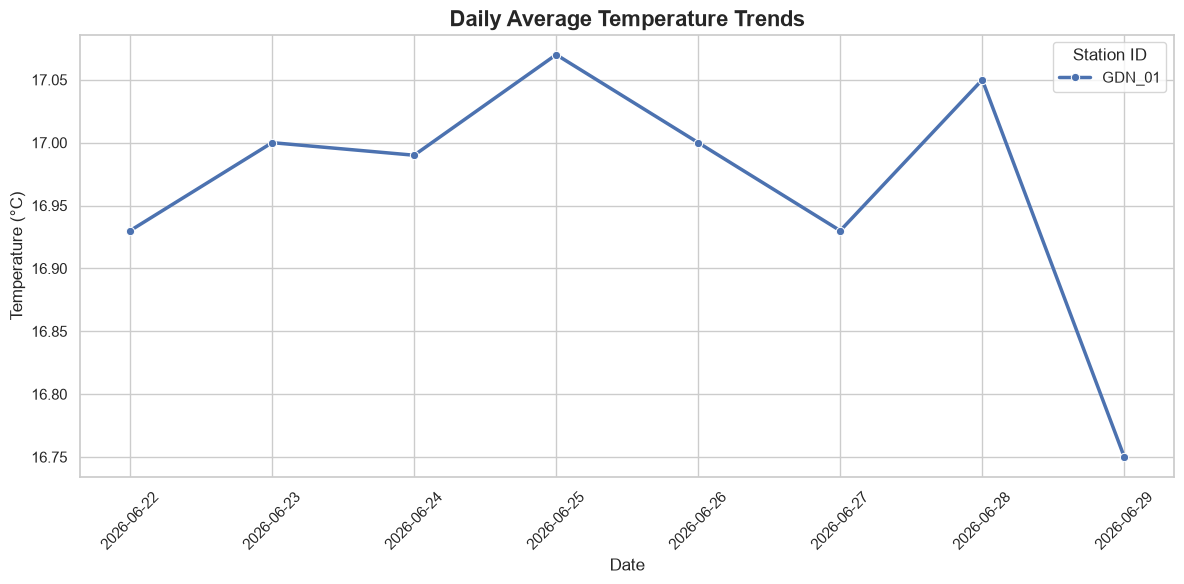

In [8]:
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

sns.lineplot(data=df_gold, x='measurement_date', y='avg_temperature', hue='station_id', marker="o", linewidth=2.5)

plt.title('Daily Average Temperature Trends', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Station ID')
plt.tight_layout()
plt.show()

## 2. Total Precipitation Analysis
Illustrations of the cumulative rainfall recorded per station during the observation period.

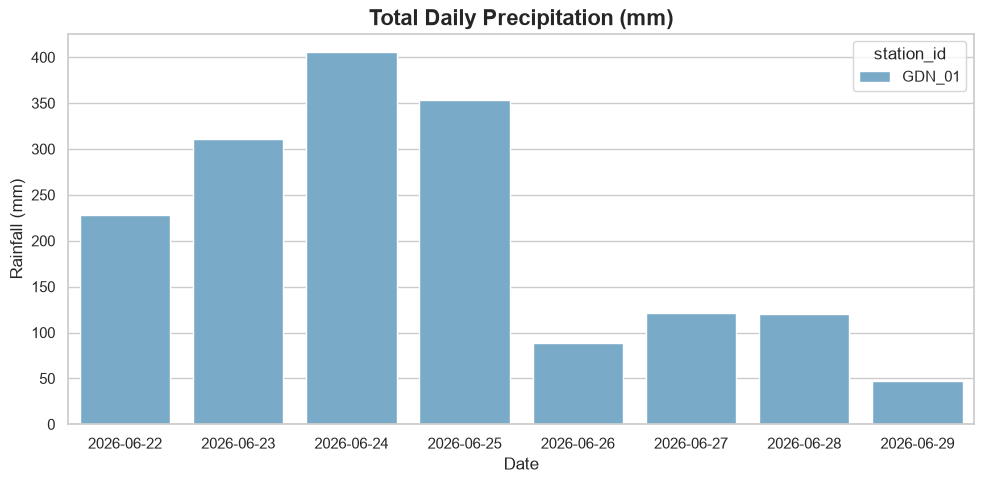

In [9]:
plt.figure(figsize=(10, 5))

sns.barplot(data=df_gold, x='measurement_date', y='total_rain_mm', hue='station_id', palette="Blues_r")

plt.title('Total Daily Precipitation (mm)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Rainfall (mm)', fontsize=12)
plt.tight_layout()
plt.show()